In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
goog_daily = pd.read_csv("/content/VZ_PRICE_MOVEMENT_Data (1).csv")
goog_daily=goog_daily.rename(columns={"Price":"Date"})
goog_daily=goog_daily.drop([0,1])

goog_daily.tail(10)

,Date,Open,High,Low,Close,Volume
2506,2025-10-22,38.31883395117773,38.93859716901777,37.68938485513885,38.541561126708984,31009500
2507,2025-10-23,38.531878063266255,38.59966443279057,37.17614328461985,37.185829162597656,52663600
2508,2025-10-24,37.37949958511798,37.68938116368693,37.32139909793618,37.59254455566406,27485700
2509,2025-10-27,37.58286385908797,38.047686245327505,37.54412773671469,37.98958206176758,27487200
2510,2025-10-28,37.91211347140118,38.270413367778964,37.71843655381753,38.07673645019531,30719200
2511,2025-10-29,39.635830243130044,40.013498200319745,38.41566824935413,38.938594818115234,53730200
2512,2025-10-30,38.75460397815109,38.919226957639545,37.544127855747874,37.728118896484375,47371000
2513,2025-10-31,37.747487903117914,38.69650076356046,37.55381097986677,38.48345947265625,52181800
2514,2025-11-03,38.26072873688792,38.35756904587527,37.61191529003295,38.22199630737305,39851100
2515,2025-11-04,38.318831673654884,38.41566828540674,37.93147783848759,38.07673645019531,33632800


In [ ]:
quart_balance=pd.read_csv("VZ_QUARTERLY_BALANCE_SHEET.csv")

quart_balance=quart_balance.drop(columns=["Net Debt"])
quart_balance=quart_balance.drop([5], errors='ignore')
quart_balance=quart_balance.rename(columns={"Unnamed: 0":"Filing_date"})

quart_balance=quart_balance.sort_values(by="Filing_date")
# quart_balance.head(10)
print(quart_balance.columns)

FileNotFoundError: [Errno 2] No such file or directory: 'VZ_QUARTERLY_BALANCE_SHEET.csv'

Quarterly Financial Table: Here I will use data in the quarterly financial report to create time series columns that I can insert into the daily price movement dataframe

In [ ]:
quart_fin=pd.read_csv("VZ_QUARTERLY_FINANCIALS.csv")
# quart_fin=quart_fin.drop([5])
quart_fin=quart_fin.rename(columns={"Unnamed: 0":"Filing_date"})
quart_fin=quart_fin.sort_values(by="Filing_date")
# quart_fin.head(10)
quart_fin.columns
# quart_fin.info()

FileNotFoundError: [Errno 2] No such file or directory: 'VZ_QUARTERLY_FINANCIALS.csv'

Below I am adding new data to the net income table so I can create rolling data for the entire daily set

In [ ]:
long_data = pd.read_csv("/content/verizon long.csv")
# long_data.info()
cleaned_column = long_data["Net income (m)"].str.replace(",", "").str.replace("$", "")
long_data["Net income (m)"] = pd.to_numeric(cleaned_column)
long_data["Net income (m)"] = long_data["Net income (m)"] * 1000000

cleaned_column = long_data["Shares Outstanding (m)"].str.replace(",", "").str.replace("$", "")
long_data["Shares Outstanding (m)"] = pd.to_numeric(cleaned_column)
long_data["Shares Outstanding (m)"] = long_data["Shares Outstanding (m)"] * 1000000

long_data=long_data.sort_values(by="date")

long_data=long_data.rename(columns={"date":"Date Filed", "Net income (m)":"Net Income"})
long_data=long_data.rename(columns={"Shares Outstanding (m)":"Shares Outstanding"})
long_data.head(10)
long_data.info()

long_data['ttm_net_income'] = long_data['Net Income'].rolling(window=4).sum()
long_data['ttm_eps'] = long_data['ttm_net_income'] / long_data['Shares Outstanding']
long_data=long_data.dropna()
long_data.head(25)
# long_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 47 to 0
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Date Filed          48 non-null     object
 1   Net Income          48 non-null     int64 
 2   Shares Outstanding  48 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.5+ KB


,Date Filed,Net Income,Shares Outstanding,ttm_net_income,ttm_eps
44,2014-12-31,-2231000000,3981000000,9.625000e+09,2.417734
43,2015-03-31,4219000000,4121000000,9.897000e+09,2.401602
42,2015-06-30,4231000000,4085000000,9.914000e+09,2.426928
41,2015-09-30,4038000000,4078000000,1.025700e+10,2.515204
40,2015-12-31,5391000000,4093000000,1.787900e+10,4.368190
39,2016-03-31,4310000000,4085000000,1.797000e+10,4.399021
38,2016-06-30,702000000,4085000000,1.444100e+10,3.535129
37,2016-09-30,3620000000,4086000000,1.402300e+10,3.431963
36,2016-12-31,4495000000,4086000000,1.312700e+10,3.212677
35,2017-03-31,3450000000,4087000000,1.226700e+10,3.001468


In [ ]:
#convert from sting to date
goog_daily['Date'] = pd.to_datetime(goog_daily['Date'])
long_data['Date Filed'] = pd.to_datetime(long_data['Date Filed'])
goog_daily.head()

,Date,Open,High,Low,Close,Volume
2,2015-11-05,26.550769805908203,26.68294869769471,26.493299292777603,26.550769805908203,11646900
3,2015-11-06,26.43008180318809,26.45306781336961,26.02779702929024,26.30939483642578,14144400
4,2015-11-09,26.165717672925794,26.171465818758197,25.878371765013934,26.033538818359375,10743200
5,2015-11-10,26.01630457493298,26.050786880801514,25.74619865965226,25.91860580444336,9996700
6,2015-11-11,26.068026426728448,26.171471150031,25.93584754523646,26.0450382232666,7904000


In [ ]:
goog_daily_plus = pd.merge_asof( #merge goog daily with long data which contains eps, etc
    goog_daily,
    long_data[['Date Filed', 'ttm_eps']],
    left_on='Date',
    right_on='Date Filed',
    direction='backward'
)

for col in goog_daily_plus.select_dtypes(include=['object']).columns:
    if goog_daily_plus[col].dtype == 'object':
        goog_daily_plus[col] = goog_daily_plus[col].replace({',': '', '\$': ''}, regex=True)
        goog_daily_plus[col] = pd.to_numeric(goog_daily_plus[col], errors='coerce')


goog_daily_plus=goog_daily_plus.drop(columns={"Date Filed"})
goog_daily_plus.head(10)

<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:11: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_1331/3589847829.py:11: SyntaxWarning: invalid escape sequence '\$'
  goog_daily_plus[col] = goog_daily_plus[col].replace({',': '', '\$': ''}, regex=True)


,Date,Open,High,Low,Close,Volume,ttm_eps
0,2015-11-05,26.550770,26.682949,26.493299,26.550770,11646900,2.515204
1,2015-11-06,26.430082,26.453068,26.027797,26.309395,14144400,2.515204
2,2015-11-09,26.165718,26.171466,25.878372,26.033539,10743200,2.515204
3,2015-11-10,26.016305,26.050787,25.746199,25.918606,9996700,2.515204
4,2015-11-11,26.068026,26.171471,25.935848,26.045038,7904000,2.515204
5,2015-11-12,25.872624,25.912852,25.728951,25.763433,11053500,2.515204
6,2015-11-13,25.705973,25.855394,25.412881,25.418627,12615600,2.515204
7,2015-11-16,25.435860,25.901361,25.389886,25.884121,10112500,2.515204
8,2015-11-17,25.866880,26.045035,25.820906,25.907110,10657500,2.515204
9,2015-11-18,25.907112,26.108253,25.619766,26.079519,13585600,2.515204


I am adding features below. SMA and EMA have to do with a moving average. I think that we will be able to tune the length of the average to acheive a higher accuracy. I will start with the 20, 50, and 200 day moving averages (50).

In [ ]:
goog_daily_plus["PE Ratio"]=goog_daily_plus["Close"]/goog_daily_plus["ttm_eps"]
goog_daily_plus['tr_1'] = goog_daily_plus['High'] - goog_daily_plus['Low']
goog_daily_plus['tr_2'] = abs(goog_daily_plus['High'] - goog_daily_plus['Close'].shift(1))
goog_daily_plus['tr_3'] = abs(goog_daily_plus['Low'] - goog_daily_plus['Close'].shift(1))
goog_daily_plus['Max_Swing'] = goog_daily_plus[['tr_1', 'tr_2', 'tr_3']].max(axis=1)
goog_daily_plus["20-Day Average Swing"] = goog_daily_plus['Max_Swing'].rolling(window=20).mean()

#Exponential Moving average
goog_daily_plus["EMA_20"]=goog_daily_plus["Close"].ewm(span=20,adjust=True).mean()
goog_daily_plus["EMA_50"]=goog_daily_plus["Close"].ewm(span=50,adjust=True).mean()
#Simple Moving Average
goog_daily_plus["SMA_20"]=goog_daily_plus["Close"].rolling(window=20).mean()
goog_daily_plus["SMA_50"]=goog_daily_plus["Close"].rolling(window=50).mean()

#Volume moving average
goog_daily_plus['VMA_20'] = goog_daily_plus['Volume'].rolling(window=20).mean()
goog_daily_plus['VMA_50'] = goog_daily_plus['Volume'].rolling(window=50).mean()

#Relative Volume
goog_daily_plus['Relative Volume_20'] = goog_daily_plus["Volume"]/goog_daily_plus['VMA_20']
goog_daily_plus['Relative Volume_50'] = goog_daily_plus["Volume"]/goog_daily_plus['VMA_50']

goog_daily_plus.info()
# goog_daily_plus.head(50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  2514 non-null   datetime64[ns]
 1   Open                  2514 non-null   float64       
 2   High                  2514 non-null   float64       
 3   Low                   2514 non-null   float64       
 4   Close                 2514 non-null   float64       
 5   Volume                2514 non-null   int64         
 6   ttm_eps               2514 non-null   float64       
 7   PE Ratio              2514 non-null   float64       
 8   tr_1                  2514 non-null   float64       
 9   tr_2                  2513 non-null   float64       
 10  tr_3                  2513 non-null   float64       
 11  Max_Swing             2514 non-null   float64       
 12  20-Day Average Swing  2495 non-null   float64       
 13  EMA_20            

Below I want to take features from the above table that I will use in the transformer to predict future price movement

In [ ]:
#need to add sentiment score to this table (from vader analysis)
final_df=goog_daily_plus[["Date", "Close", "SMA_20", "SMA_50", "EMA_20", "EMA_50", "Volume", "Relative Volume_20", "Relative Volume_50", "20-Day Average Swing", "PE Ratio"]]
final_df=final_df.rename(columns={"Close":"Price"})
final_df=final_df.drop(final_df.index[:49])
# final_df.set_index("Date", inplace=True)
final_df.head(5)
# final_df.info()


,Date,Price,SMA_20,SMA_50,EMA_20,EMA_50,Volume,Relative Volume_20,Relative Volume_50,20-Day Average Swing,PE Ratio
49,2016-01-19,26.103600,26.427457,26.212142,26.256884,26.269084,20364300,1.320774,1.489927,0.406999,5.975839
50,2016-01-20,25.841801,26.410399,26.197963,26.217111,26.249825,28290200,1.854948,2.020606,0.422897,5.915906
51,2016-01-21,26.685356,26.425749,26.205482,26.261952,26.269342,31354100,1.923460,2.185710,0.466962,6.109020
52,2016-01-22,27.366013,26.462488,26.232132,26.367626,26.318213,23075700,1.365782,1.581427,0.485794,6.264841
53,2016-01-25,27.360201,26.481409,26.260963,26.462584,26.364400,24298800,1.390389,1.633233,0.498588,6.263510


<Axes: >

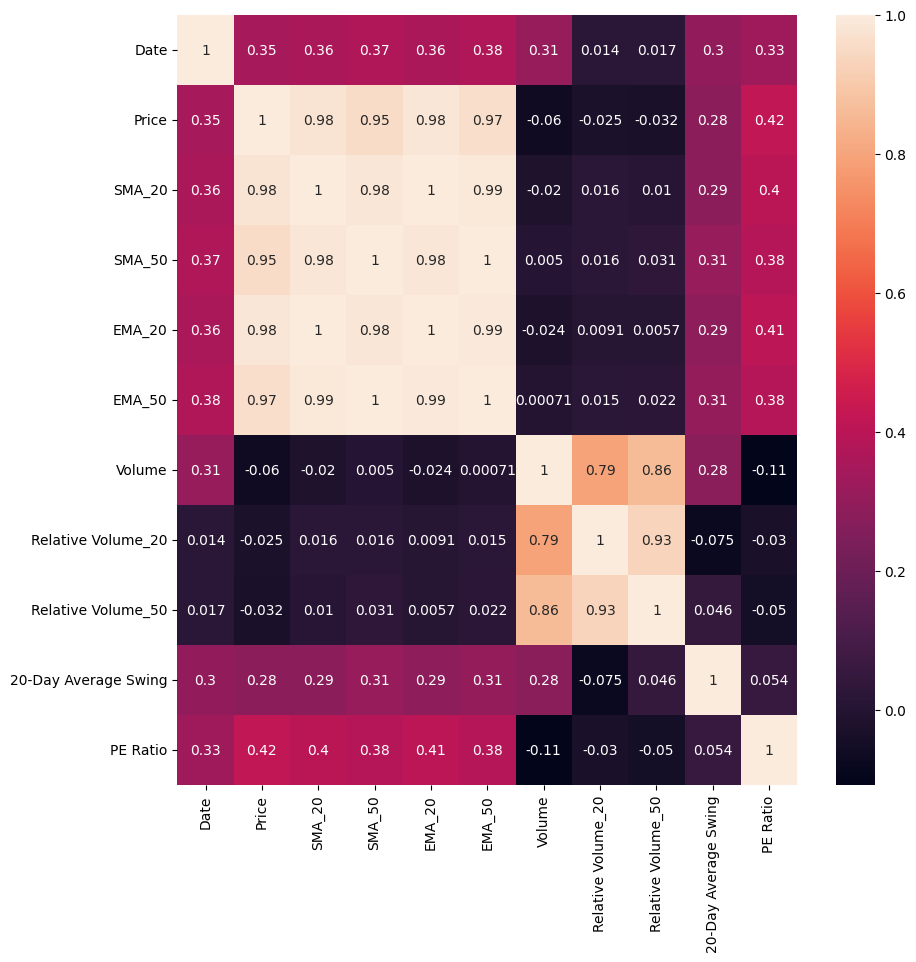

In [ ]:
final_df.to_csv("VZ_final_DF.csv", index=False)
corr_mat=final_df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_mat,annot=True)

<Axes: >

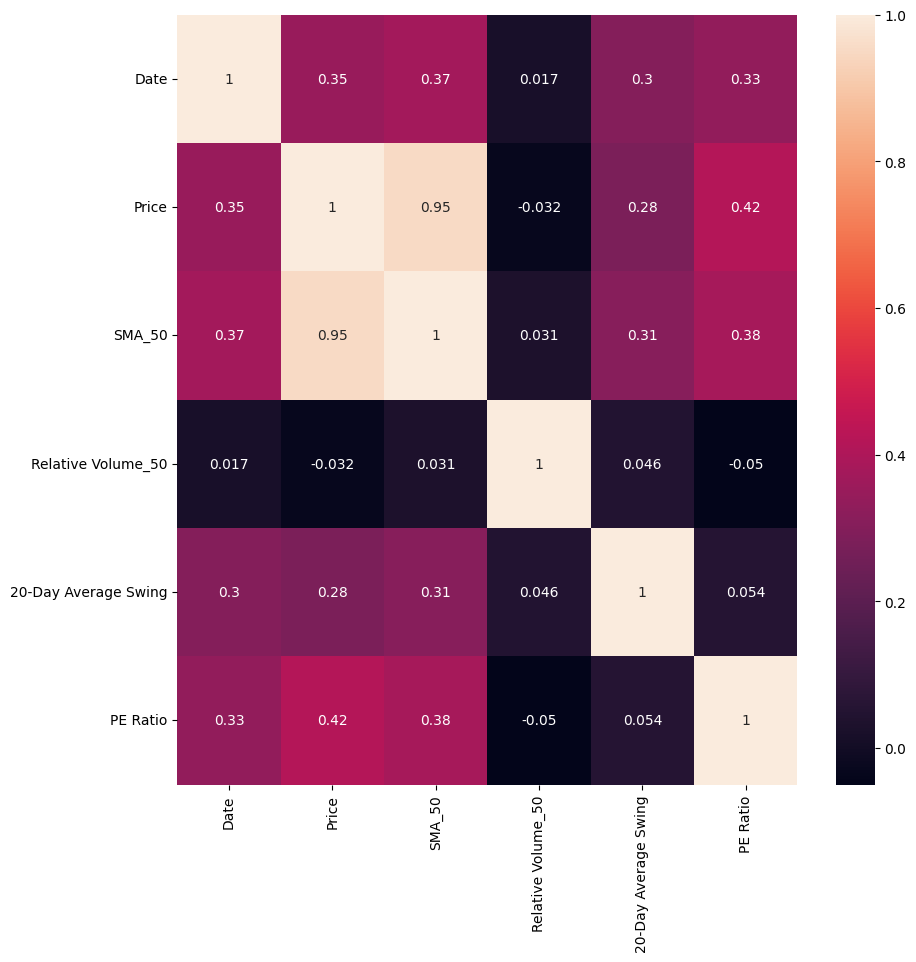

In [ ]:
final_df=pd.read_csv("VZ_final_DF.csv")
final_df['Date'] = pd.to_datetime(final_df['Date'])
reduced_df=final_df.drop(columns=["Volume","SMA_20","EMA_20", "EMA_50","Relative Volume_20"])
# reduced_df.head()
reduced_corr=reduced_df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(reduced_corr,annot=True)

LSTM implimentation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


Below is an attempt with the full Final Dataframe

In [ ]:
if 'Date' in final_df.columns:
    final_df = final_df.set_index('Date')


target_col = 'Price'
feature_cols = [col for col in final_df.columns if col != target_col]
n_features = len(feature_cols)

feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

df_target = final_df[[target_col]].values
df_features = final_df[feature_cols].values

scaled_target = target_scaler.fit_transform(df_target)
scaled_features = feature_scaler.fit_transform(df_features)

scaled_data = np.concatenate([scaled_target, scaled_features], axis=1)

train_split_ratio = 0.8
train_size = int(len(scaled_data) * train_split_ratio)
test_size = len(scaled_data) - train_size

train_data = scaled_data[0:train_size, :]
test_data = scaled_data[train_size:, :]

print(f"Number of features (not including target): {n_features}")
print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

In [ ]:
def create_sequences_simple(data, seq_length):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, :])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

seq_length = 180
n_all_features = scaled_data.shape[1]

X_train, y_train = create_sequences_simple(train_data, seq_length)

test_data_with_overlap = scaled_data[train_size - seq_length:, :]
X_test, y_test_scaled = create_sequences_simple(test_data_with_overlap, seq_length)

y_test_actual = final_df[target_col].iloc[train_size:].values
# print(X_train)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

In [ ]:
n_timesteps = 180
n_features = 9

model = Sequential()

model.add(LSTM(units=200, return_sequences=True, input_shape=(seq_length, n_all_features)))
model.add(Dropout(0.2))

model.add(LSTM(units=200, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=200, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=100, activation='relu'))

model.add(Dense(units=1))

model.summary()

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')

print("Training new model...")
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=200,
    validation_data=(X_test, y_test_scaled),
    verbose=1
)
print("Model training complete.")

In [ ]:
model.save_weights("Large_GOOG_weights.weights.h5")

In [ ]:
from sklearn.metrics import mean_squared_error

predictions_scaled = model.predict(X_test)

predictions = target_scaler.inverse_transform(predictions_scaled)

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f'Test Root Mean Squared Error (RMSE): {rmse}')

train_dates = final_df.index[seq_length:train_size]
test_dates = final_df.index[train_size:]
actual_train_data = final_df[target_col].iloc[seq_length:train_size]

plt.figure(figsize=(16, 8))
plt.plot(train_dates, actual_train_data, color='gray', label='Actual Price (Train)')
plt.plot(test_dates, y_test_actual, color='blue', label='Actual Price (Test)')
plt.plot(test_dates, predictions, color='red', label='Predicted Price', alpha=0.7)
plt.title(f'Simple Model Backtest (RMSE: {rmse:.2f})')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
n_future_days = 90
seq_length = 180

last_known_sequence = scaled_data[-seq_length:]

future_predictions_scaled = []

current_sequence = last_known_sequence

print(f"Starting simple forecast loop for {n_future_days} days...")
for i in range(n_future_days):
    current_sequence_reshaped = np.reshape(current_sequence, (1, seq_length, n_all_features))

    next_prediction_scaled = model.predict(current_sequence_reshaped, verbose=0)

    future_predictions_scaled.append(next_prediction_scaled[0][0])

    new_row = current_sequence[-1, :].copy()

    new_row[0] = next_prediction_scaled[0][0]

    current_sequence = np.append(current_sequence, [new_row], axis=0)
    current_sequence = current_sequence[1:, :]

print("Forecast loop complete.")

predictions = target_scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

last_date = final_df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_future_days)

last_actual_price = final_df[target_col].iloc[-1]
last_actual_date = final_df.index[-1]

plot_predictions = np.insert(predictions, 0, last_actual_price)
plot_dates = future_dates.insert(0, last_actual_date)

plt.figure(figsize=(16, 8))
plt.plot(final_df.index, final_df[target_col], color='blue', label='Actual Historical Price')
plt.plot(plot_dates, plot_predictions, color='red', linestyle='--', label='Future Forecast (Simple)')
plt.title('Stock Price History and 1-quarter "Honest" Simple Forecast')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

Attempt with reduced dataframe

In [ ]:
if 'Date' in reduced_df.columns:
    reduced_df = reduced_df.set_index('Date')


target_col = 'Price'
feature_cols = [col for col in reduced_df.columns if col != target_col]
n_features = len(feature_cols)

feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

df_target = reduced_df[[target_col]].values
df_features = reduced_df[feature_cols].values

scaled_target = target_scaler.fit_transform(df_target)
scaled_features = feature_scaler.fit_transform(df_features)

scaled_data = np.concatenate([scaled_target, scaled_features], axis=1)

train_split_ratio = 0.8
train_size = int(len(scaled_data) * train_split_ratio)
test_size = len(scaled_data) - train_size

train_data = scaled_data[0:train_size, :]
test_data = scaled_data[train_size:, :]

print(f"Number of features (not including target): {n_features}")
print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

In [ ]:
def create_sequences_simple(data, seq_length):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, :])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

seq_length = 180
n_all_features = scaled_data.shape[1]

X_train, y_train = create_sequences_simple(train_data, seq_length)

test_data_with_overlap = scaled_data[train_size - seq_length:, :]
X_test, y_test_scaled = create_sequences_simple(test_data_with_overlap, seq_length)

y_test_actual = reduced_df[target_col].iloc[train_size:].values
# print(X_train)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

In [ ]:
reduced_df.columns

In [ ]:
n_timesteps = 180
n_features = 4

model = Sequential()

model.add(LSTM(units=400, return_sequences=True, input_shape=(seq_length, n_all_features)))
model.add(Dropout(0.2))

model.add(LSTM(units=400, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=400, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=400, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=200, activation='relu'))

model.add(Dense(units=100, activation='relu'))

# model.add(Dense(units=n_features))
model.add(Dense(units=1))

model.summary()

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')

print("Training new model...")
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=200,
    validation_data=(X_test, y_test_scaled),
    verbose=1
)
print("Model training complete.")



In [ ]:
model.save_weights("reduced_weights_Large_model1.weights.h5")

In [ ]:
model.load_weights("reduced_weights.weights.h5")


In [ ]:
from sklearn.metrics import mean_squared_error

predictions_scaled = model.predict(X_test)

predictions = target_scaler.inverse_transform(predictions_scaled)

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f'Test Root Mean Squared Error (RMSE): {rmse}')

train_dates = final_df.index[seq_length:train_size]
test_dates = final_df.index[train_size:]
actual_train_data = final_df[target_col].iloc[seq_length:train_size]

plt.figure(figsize=(16, 8))
plt.plot(train_dates, actual_train_data, color='gray', label='Actual Price (Train)')
plt.plot(test_dates, y_test_actual, color='blue', label='Actual Price (Test)')
plt.plot(test_dates, predictions, color='red', label='Predicted Price', alpha=0.7)
plt.title(f'Simple Model Backtest (RMSE: {rmse:.2f})')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
n_future_days = 180
seq_length = 180

last_known_sequence = scaled_data[-seq_length:]

future_predictions_scaled = []

current_sequence = last_known_sequence

print(f"Starting simple forecast loop for {n_future_days} days...")
for i in range(n_future_days):
    current_sequence_reshaped = np.reshape(current_sequence, (1, seq_length, n_all_features))

    next_prediction_scaled = model.predict(current_sequence_reshaped, verbose=0)

    future_predictions_scaled.append(next_prediction_scaled[0][0])

    new_row = current_sequence[-1, :].copy()

    new_row[0] = next_prediction_scaled[0][0]

    current_sequence = np.append(current_sequence, [new_row], axis=0)
    current_sequence = current_sequence[1:, :]

print("Forecast loop complete.")

predictions = target_scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

last_date = reduced_df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_future_days)

last_actual_price = reduced_df[target_col].iloc[-1]
last_actual_date = reduced_df.index[-1]

plot_predictions = np.insert(predictions, 0, last_actual_price)
plot_dates = future_dates.insert(0, last_actual_date)

plt.figure(figsize=(16, 8))
plt.plot(reduced_df.index, reduced_df[target_col], color='blue', label='Actual Historical Price')
plt.plot(plot_dates, plot_predictions, color='red', linestyle='--', label='Future Forecast (Simple)')
plt.title('Stock Price History and 1-quarter "Honest" Simple Forecast')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(reduced_df.index[-365:], reduced_df[target_col][-365:], color='blue', label='Actual Historical Price')
plt.plot(plot_dates, plot_predictions, color='red', linestyle='-.', label='Future Forecast (Simple)')
plt.title('Stock Price History and 1-quarter "Honest" Simple Forecast')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

Single Feature


In [ ]:
# --- Data Preparation and Scaling (Single Feature) ---

target_col = 'Price'
df_target = reduced_df[[target_col]].values

# Use a dedicated scaler for the single 'Price' feature
target_scaler_single = MinMaxScaler(feature_range=(0, 1))
scaled_target_data = target_scaler_single.fit_transform(df_target)

# --- Splitting ---
seq_length = 180
train_split_ratio = 0.8
train_size = int(len(scaled_target_data) * train_split_ratio)
train_data_single = scaled_target_data[0:train_size, :]

# --- Sequence Creation for Single Feature ---
def create_sequences_single_feature(data, seq_length):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        # X: sequence of past 'seq_length' data points
        X.append(data[i-seq_length:i, 0])
        # y: the next data point (the target at index 0)
        y.append(data[i, 0])

    # X needs shape (n_samples, seq_length, 1) for LSTM
    X = np.array(X)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))

    return X, np.array(y)

# Create train sequences
X_train_single, y_train_single = create_sequences_single_feature(train_data_single, seq_length)
n_features_single = 1

In [ ]:
n_timesteps = 180
n_features_single = 1

model_single = Sequential()

# Input shape is (seq_length, 1)
model_single.add(LSTM(units=100, return_sequences=True, input_shape=(n_timesteps, n_features_single)))
model_single.add(Dropout(0.2))

model_single.add(LSTM(units=100, return_sequences=True))
model_single.add(Dropout(0.2))

model_single.add(LSTM(units=100, return_sequences=False))
model_single.add(Dropout(0.2))

model_single.add(Dense(units=50, activation='relu'))
model_single.add(Dense(units=1))

model_single.compile(optimizer='adam', loss='mean_squared_error')

print("Starting single feature model training...")
# Only 20 epochs to demonstrate the fix, feel free to increase this.
history_single = model_single.fit(
    X_train_single,
    y_train_single,
    epochs=20, # Reduced epochs for demonstration, increase if needed
    batch_size=32,
    verbose=1
)
print("Single feature model training complete.")

In [ ]:
n_future_days = 180
seq_length = 180

# Get the last 'seq_length' days of SCALED data (shape: 180, 1)
last_known_sequence = scaled_target_data[-seq_length:]

future_predictions_scaled = []
current_sequence = last_known_sequence.copy()

print(f"Starting single-feature future price forecast for {n_future_days} days...")

# The loop runs for the number of days we want to forecast
for i in range(n_future_days):

    # 1. Reshape the current sequence for the LSTM model: (1, seq_length, 1)
    current_sequence_reshaped = np.reshape(current_sequence, (1, seq_length, 1))

    # 2. Predict the next day's price (still scaled) - Output shape is (1, 1)
    next_prediction_scaled = model_single.predict(current_sequence_reshaped, verbose=0)

    # 3. Store the prediction (the scalar value)
    future_predictions_scaled.append(next_prediction_scaled[0][0])

    # 4. Update the current_sequence for the next prediction (Iterative/Autoregressive step)

    # Drop the oldest day (current_sequence[1:] has shape (179, 1))
    # Append the new prediction (next_prediction_scaled has shape (1, 1))
    # Concatenate along axis=0 to get back to the required (180, 1) shape.
    current_sequence = np.concatenate([current_sequence[1:], next_prediction_scaled], axis=0)

print("Future forecast loop complete.")

# Inverse transform the scaled predictions to get actual dollar values
predictions_actual_single = target_scaler_single.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

# --- Plotting the Historical Data + Future Forecast ---

last_actual_date = reduced_df.index[-1]

# Generate future dates starting from the day after the last historical date
future_dates = pd.date_range(start=last_actual_date + pd.Timedelta(days=1), periods=n_future_days)

# Prepare predictions for plotting, starting from the last known actual price
last_actual_price = reduced_df[target_col].iloc[-1]
plot_predictions = np.insert(predictions_actual_single, 0, last_actual_price)
plot_dates = future_dates.insert(0, last_actual_date)

plt.figure(figsize=(16, 8))
plt.plot(reduced_df.index, reduced_df[target_col], color='blue', label='Actual Historical Price')
plt.plot(plot_dates, plot_predictions, color='red', linestyle='--', label='Future Forecast (180 Days)')
plt.title('Stock Price History and Single-Feature LSTM Forecast')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()